Direction dependency check:
  a_2^B = [-1.  1.]
  a_3^B = [1. 0.]
  a_4^B = [0. 1.]
  a_2^B + a_3^B = [0. 1.]
  a_4^B - (a_2^B + a_3^B) = [0. 0.]  (zero ✓)

  => Only 3 independent directions => hull ≤ hexagon.

  d = (1, 1, 1, 1)   q0 = (0.0, 0.0)
  ----------------------------------
    𝔖      σ             Q1        Q2  status
  --------------------------------------------------
    1  (+,+,+,-)     -1.000    -1.000  interior
    2  (+,+,-,-)     -3.000    -1.000  hull
    3  (+,-,-,+)     -1.000    -1.000  interior
    4  (+,-,-,-)     -1.000    -3.000  hull
    5  (-,+,+,+)      1.000     3.000  hull
    6  (-,+,+,-)      1.000     1.000  interior
    7  (-,-,+,+)      3.000     1.000  hull
    8  (-,-,-,+)      1.000     1.000  interior

  Hull: 4-gon   (4 of 8 vertices on hull)

  d = (1, 2, 3, 4)   q0 = (0.0, 0.0)
  ----------------------------------
    𝔖      σ             Q1        Q2  status
  --------------------------------------------------
    1  (+,+,+,-)      0.000   

/tmp/ipykernel_2421/94746210.py:228: UserWarning: Glyph 120086 (\N{MATHEMATICAL FRAKTUR CAPITAL S}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2421/94746210.py:274: UserWarning: Glyph 120086 (\N{MATHEMATICAL FRAKTUR CAPITAL S}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=150, bbox_inches="tight")


Plot saved to /home/daksh/nnpdf/myScripts/zonotope_hulls.png


/home/daksh/anaconda3/envs/environment_nnpdf/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120086 (\N{MATHEMATICAL FRAKTUR CAPITAL S}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


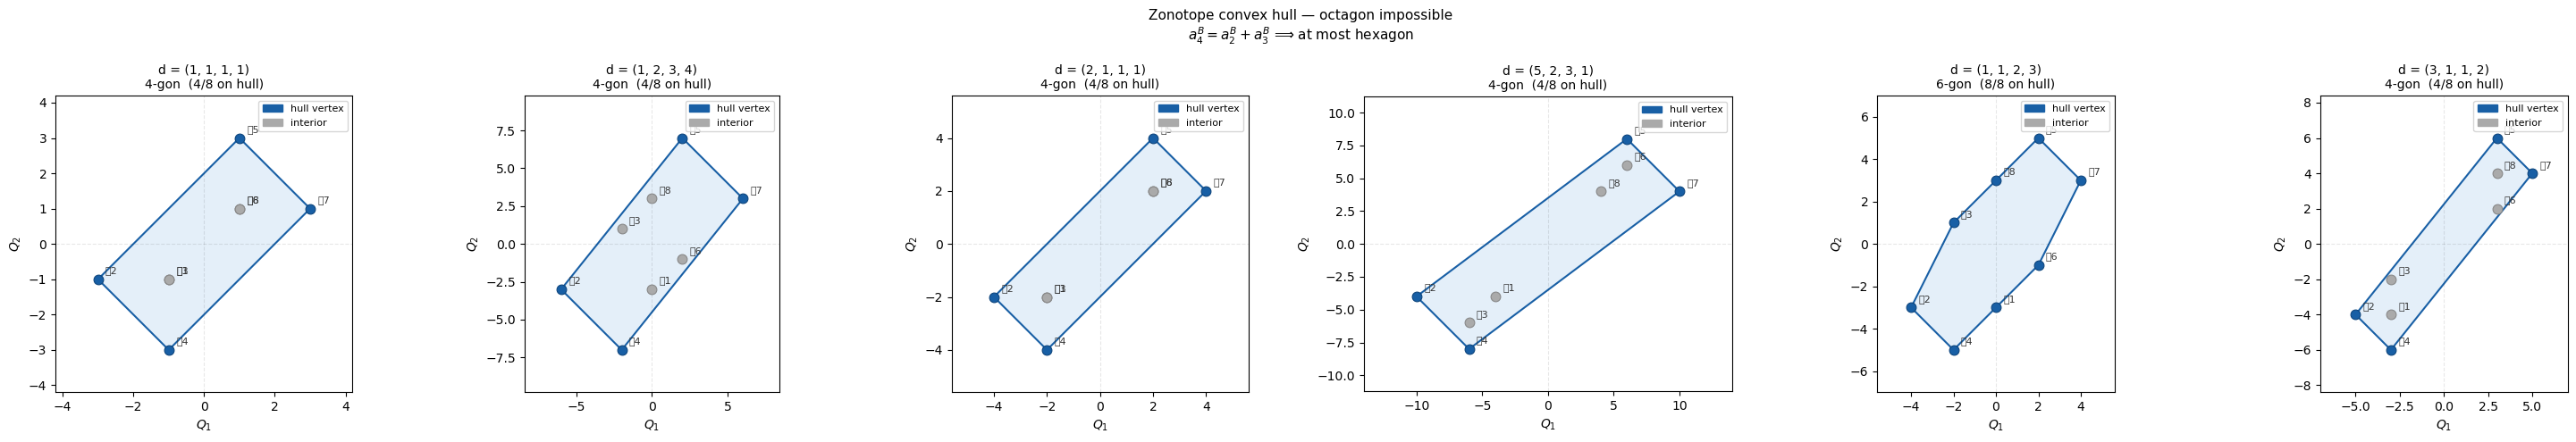

In [ ]:
"""
Zonotope convex hull analysis.

Vertices are given by:
    q^sigma = q0 + \sum_{e \in E}d_e * \sigma_e * a_e^B (the generator)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import ConvexHull

# ---------------------------------------------------------------------------
# Example Data (for the non-graphical matroid)
# ---------------------------------------------------------------------------

ORIENTATIONS = [
    ("1", [+1, +1, +1, -1]),
    ("2", [+1, +1, -1, -1]),
    ("3", [+1, -1, -1, +1]),
    ("4", [+1, -1, -1, -1]),
    ("5", [-1, +1, +1, +1]),
    ("6", [-1, +1, +1, -1]),
    ("7", [-1, -1, +1, +1]),
    ("8", [-1, -1, -1, +1]),
]

# Columns of the generator matrix  (each row is a_e^B)
DIRS = np.array([
    [-1, -1],   # a_1^B
    [-1, +1],   # a_2^B
    [+1,  0],   # a_3^B
    [ 0, +1],   # a_4^B
], dtype=float)


# ---------------------------------------------------------------------------
# Core computation
# ---------------------------------------------------------------------------

def get_vertices(d, q0=(0.0, 0.0)):
    """
    Returns the 8 sigma-vertices as an (8, 2) array.

    Parameters
    ----------
    d  : array-like of length 4  (d_1, d_2, d_3, d_4)
    q0 : base point (default origin)
    """
    d = np.asarray(d, dtype=float)
    q0 = np.asarray(q0, dtype=float)
    verts = []
    for _, sigma in ORIENTATIONS:
        sigma = np.array(sigma, dtype=float)
        # q = q0 + sum_e  sigma_e * d_e * a_e^B
        q = q0 + (sigma * d) @ DIRS        # shape (2,)
        verts.append(q)
    return np.array(verts)                 # (8, 2)


def analyse(d, q0=(0.0, 0.0)):
    """
    Compute vertices, convex hull, and classify each sigma-vertex.

    Returns a dict with keys:
        vertices    (8, 2) array
        hull        scipy ConvexHull object  (or None if degenerate)
        on_hull     bool array of length 8
        n_sides     number of hull edges
        collinear   indices of hull vertices that are collinear with neighbors
    """
    verts = get_vertices(d, q0)

    # Unique points (needed for ConvexHull)
    _, unique_idx = np.unique(verts.round(9), axis=0, return_index=True)
    unique_pts = verts[sorted(unique_idx)]

    if len(unique_pts) < 3:
        return dict(vertices=verts, hull=None, on_hull=np.zeros(8, bool),
                    n_sides=0, collinear=[])

    hull = ConvexHull(unique_pts)

    # Mark each of the 8 vertices as on-hull or interior
    hull_pts = unique_pts[hull.vertices]
    on_hull = _points_on_hull(verts, hull_pts, hull, unique_pts)

    # Detect collinear consecutive hull corners
    collinear = _find_collinear(hull_pts)

    return dict(vertices=verts, hull=hull, hull_pts=hull_pts,
                on_hull=on_hull, n_sides=len(hull.vertices),
                collinear=collinear, unique_pts=unique_pts)


def _points_on_hull(pts, hull_pts, hull, unique_pts):
    """Return bool array: True if pt (short for point) lies on the hull boundary."""
    n_h = len(hull_pts)
    on = np.zeros(len(pts), dtype=bool)
    for i, p in enumerate(pts):
        # Exact vertex match
        if np.any(np.all(np.abs(hull_pts - p) < 1e-9, axis=1)):
            on[i] = True
            continue
        # On an edge
        for j in range(n_h):
            a, b = hull_pts[j], hull_pts[(j + 1) % n_h]
            if _on_segment(p, a, b):
                on[i] = True
                break
    return on


def _cross2d(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def _on_segment(p, a, b, tol=1e-9):
    if abs(_cross2d(a, b, p)) > tol:
        return False
    return (min(a[0], b[0]) - tol <= p[0] <= max(a[0], b[0]) + tol and
            min(a[1], b[1]) - tol <= p[1] <= max(a[1], b[1]) + tol)


def _find_collinear(hull_pts):
    """Indices in hull_pts that are collinear with their neighbors."""
    n = len(hull_pts)
    bad = []
    for i in range(n):
        a, b, c = hull_pts[(i - 1) % n], hull_pts[i], hull_pts[(i + 1) % n]
        if abs(_cross2d(a, b, c)) < 1e-9:
            bad.append(i)
    return bad


# ---------------------------------------------------------------------------
# print table
# ---------------------------------------------------------------------------

def print_table(d, q0=(0.0, 0.0)):
    res = analyse(d, q0)
    verts = res["vertices"]
    on_hull = res["on_hull"]

    header = f"  d = {tuple(d)}   q0 = {q0}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    print(f"  {'𝔖':>3}  {'σ':^10}  {'Q1':>8}  {'Q2':>8}  {'status'}")
    print("  " + "-" * 50)
    for idx, (name, sigma) in enumerate(ORIENTATIONS):
        sigma_str = "(" + ",".join("+" if s > 0 else "-" for s in sigma) + ")"
        status = "hull" if on_hull[idx] else "interior"
        print(f"  {name:>3}  {sigma_str:^10}  {verts[idx,0]:>8.3f}  {verts[idx,1]:>8.3f}  {status}")
    print(f"\n  Hull: {res['n_sides']}-gon   "
          f"({on_hull.sum()} of 8 vertices on hull)")
    if res["collinear"]:
        print(f"  ⚠  {len(res['collinear'])} hull corner(s) collinear with neighbors")
    print()


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

def plot(d_list, q0=(0.0, 0.0), figsize=None):
    """
    Plot the zonotope convex hull for one or several d vectors side-by-side.

    Parameters
    ----------
    d_list  : list of array-like, each of length 4
    q0      : base point
    figsize : optional figure size tuple
    """
    n = len(d_list)
        
    fig, axes = plt.subplots(1, n,
                             figsize=figsize or (5 * n, 5),
                             squeeze=False)

    for ax, d in zip(axes[0], d_list):
        res = analyse(d, q0)
        verts   = res["vertices"]
        on_hull = res["on_hull"]
        hull_pts = res.get("hull_pts", np.zeros((0, 2)))

        # --- Hull polygon ---
        if res["hull"] is not None:
            poly = plt.Polygon(hull_pts, closed=True,
                               facecolor="#3B8BD422", edgecolor="#185FA5",
                               linewidth=1.5, zorder=1)
            ax.add_patch(poly)

        # --- Vertices ---
        for i, (name, sigma) in enumerate(ORIENTATIONS):
            color = "#185FA5" if on_hull[i] else "#aaaaaa"
            ax.scatter(*verts[i], color=color, s=60, zorder=3,
                       edgecolors="#0C447C" if on_hull[i] else "#888888",
                       linewidths=0.8)
            ax.annotate(f"𝔖{name}", verts[i],
                        textcoords="offset points", xytext=(6, 4),
                        fontsize=8, color="#333333")

        # --- Axes guides ---
        ax.axhline(0, color="#00000018", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="#00000018", linewidth=0.8, linestyle="--")

        # --- Labels ---
        sides = res["n_sides"]
        ax.set_title(f"d = {tuple(d)}\n{sides}-gon  "
                     f"({on_hull.sum()}/8 on hull)", fontsize=10)
        ax.set_xlabel("$Q_1$"); ax.set_ylabel("$Q_2$")
        ax.set_aspect("equal")
        ax.margins(0.2)

        # Legend
        hull_patch    = mpatches.Patch(color="#185FA5", label="hull vertex")
        interior_patch = mpatches.Patch(color="#aaaaaa", label="interior")
        ax.legend(handles=[hull_patch, interior_patch], fontsize=8,
                  loc="upper right")

    fig.suptitle("Zonotope convex hull — octagon impossible\n"
                 r"$a_4^B = a_2^B + a_3^B$ ⟹ at most hexagon",
                 fontsize=11)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Direction-dependency proof helper
# ---------------------------------------------------------------------------

def check_direction_dependency():
    """
    Verify that a_4^B lies in the positive span of a_2^B and a_3^B,
    i.e. the direction (0,1) = (-1,1) + (1,0).
    """
    a2, a3, a4 = DIRS[1], DIRS[2], DIRS[3]
    residual = a4 - (a2 + a3)
    print("Direction dependency check:")
    print(f"  a_2^B = {a2}")
    print(f"  a_3^B = {a3}")
    print(f"  a_4^B = {a4}")
    print(f"  a_2^B + a_3^B = {a2 + a3}")
    print(f"  a_4^B - (a_2^B + a_3^B) = {residual}  "
          f"({'zero ✓' if np.allclose(residual, 0) else 'non-zero ✗'})")
    print("\n  => Only 3 independent directions => hull ≤ hexagon.\n")


# ---------------------------------------------------------------------------
# Main demo
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    check_direction_dependency()

    demo_cases = [
        [1, 1, 1, 1],
        [1, 2, 3, 4],
        [2, 1, 1, 1],
        [5, 2, 3, 1],
        [1, 1, 2, 3],
        [3, 1, 1, 2]
    ]

    for d in demo_cases:
        print_table(d)

    fig = plot(demo_cases)
    out_path = "/home/zonotope_hulls.png"  #SET PATH
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()